<a href="https://colab.research.google.com/github/Noelsip/final-task/blob/main/Tugas_Akhir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Pengaruh *Cyclical Learning Rate* terhadap Model CNN dalam Klasifikasi Citra Sintetis AI

**Dataset:** CIFAKE
****
**Kelas:** REAL dan FAKE

**Model:** *Covolution Neural Network*

**Strategi Learning Rate:** *Fixed Learning Rate* dan *Cyclical Learning Rate*

## Instalasi Pustaka

In [ ]:
import os
import gc
import math
import random
import platform
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Library Berhasil dimuat.")
print("TensorFlow : ", tf.__version__)
print("Numpy      : ", np.__version__)
print("Pandas     : ", pd.__version__)

Library Berhasil dimuat.
TensorFlow :  2.20.0
Numpy      :  2.1.3
Pandas     :  2.2.3


## Konfigurasi Eksperimen dan Reproducibility

In [ ]:
SEED = 1

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
  tf.config.experimental.enable_op_determinism()
  DETERMINISTIC_ENABLED = True
except Exception as e:
  DETERMINISTIC_ENABLED = False
  print("Peringatan Determinism: ", e)

# Datase
DATASET_ROOT = Path("/content/cifake_data")
TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"

CLASS_NAMES = ["REAL" , "FAKE"]
CLASS_TO_LABEL = {
    "REAL": 0,
    "FAKE": 1
}

# Konfigurasi Citra
IMG_HEIGHT = 32
IMG_WIDTH = 32
IMG_CHANNELS = 3
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

# Data split
VAL_RATIO = 0.10

# Konfigurasi Pelatihan
BATCH_SIZE = 32
EPOCHS = 50

# Fix Learning Rate
FIXED_LR = 1e-3

# Learning Rate Range Test
LRRT_START = 1e-10
LRRT_END = 1e-1
LRRT_EPOCHS = 5

# Cyclical Learning Rate
STEP_SIZE_MULTIPLIER = 4

BASE_LR = None
MAX_LR = None

# Hasil Eksperimen
RESULTS_DIR = Path("/content/results")
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"

print("KONFIGURASI EKSPERIMEN")
print(f"Seed                  : {SEED}")
print(f"Determinism           : {DETERMINISTIC_ENABLED}")
print(f"Image size            : {IMG_SIZE} x {IMG_CHANNELS} channel")
print(f"Batch size            : {BATCH_SIZE}")
print(f"Epoch                 : {EPOCHS}")
print(f"Fixed learning rate   : {FIXED_LR}")
print(f"LRRT start            : {LRRT_START:.1e}")
print(f"LRRT end              : {LRRT_END:.1e}")
print(f"LRRT epochs           : {LRRT_EPOCHS}")
print(f"CLR step multiplier   : {STEP_SIZE_MULTIPLIER}")

KONFIGURASI EKSPERIMEN
Seed                  : 1
Determinism           : True
Image size            : (32, 32) x 3 channel
Batch size            : 32
Epoch                 : 50
Fixed learning rate   : 0.001
LRRT start            : 1.0e-10
LRRT end              : 1.0e-01
LRRT epochs           : 5
CLR step multiplier   : 4


# Pengambilan Dataset



Dataset yang digunakan adalah CIFAKE yang terdiri atas citra REAL dan FAKE

Dataset penelitian mempertahankan:
- 100.000 citra untuk bagian training awal
- 20.000 citra untuk testing

Bagian training kemudian dibagi menjadi:
- 90.000 citra training
- 10.000 citra validation

Pembagian dilakukan secara eksplisit per kelas agar komposisinya tetap seimbang.

## Upload kaggle.json

In [ ]:
from google.colab import files

print("Silahkan upload file kaggle.json")
uploaded = files.upload()

if "kaggle.json" not in uploaded:
  raise FileNotFoundError(
      "File kaggle.json tidak ditemukan",
      "Upload file kaggle.json!!!"
  )

print("kaggle.json berhasil diupload")

Silahkan upload file kaggle.json


Saving kaggle.json to kaggle.json
kaggle.json berhasil diupload


## Download dan Ekstrak CIFAKE

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download Dataset
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images

# Ekstraksi Dataset
!rm -rf /content/cifake_data
!mkdir -p /content/cifake_data

!unzip -q cifake-real-and-ai-generated-synthetic-images.zip -d /content/cifake_data

print("Dataset berhasil diunduh dan diekstrak.")

Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
100% 105M/105M [00:01<00:00, 104MB/s] 

Dataset berhasil diunduh dan diekstrak.


## Verifikasi Dataset CIFAKE

In [ ]:
VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".gif"
}

def count_images(folder):
    folder = Path(folder)

    return sum(
        1
        for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    )


def count_class_images(folder, class_name):
    class_dir = Path(folder) / class_name

    if not class_dir.exists():
        return 0

    return sum(
        1
        for p in class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    )


print("STRUKTUR DATASET")

print("\nTrain directory:")
for class_name in CLASS_NAMES:
    print(
        f"{class_name:>5} : "
        f"{count_class_images(TRAIN_DIR, class_name):,} images"
    )

print(
    f"TOTAL : {count_images(TRAIN_DIR):,} images"
)

print("\nTest directory:")
for class_name in CLASS_NAMES:
    print(
        f"{class_name:>5} : "
        f"{count_class_images(TEST_DIR, class_name):,} images"
    )

print(
    f"TOTAL : {count_images(TEST_DIR):,} images"
)


STRUKTUR DATASET

Train directory:
 REAL : 50,000 images
 FAKE : 50,000 images
TOTAL : 100,000 images

Test directory:
 REAL : 10,000 images
 FAKE : 10,000 images
TOTAL : 20,000 images


## Pembagian Train dan Validation

In [ ]:
def collect_class_paths(root_dir, class_name):
  class_dir = Path(root_dir) / class_name

  paths = sorted([
      p
      for p in class_dir.rglob("*")
      if p.is_file() and p.suffix.lower() in VALID_EXTENTIONS
  ])
  return paths

train_paths = []
train_labels = []

val_paths = []
val_labels = []

rng = np.random.default_rng(SEED)

print("PEMBAGIAN TRAIN / VALIDATION")
print()

for class_name in CLASS_NAMES:
  label = CLASS_TO_LABEL[class_name]

  class_paths = collect_class_paths(TRAIN_DIR, class_name)

  if len(class_paths) == 0:
    raise RuntimeError(f"Tidak ada file ditemukan untuk kelas {class_name}")

  # menggunakan shuffle untuk menentukan split
  rng.shuffle(class_paths)

  n_validation = int(len(class_paths) * VAL_RATIO)

  class_val_paths = class_paths[:n_validation]
  class_train_paths = class_paths[n_validation:]

  train_paths.extend(class_train_paths)
  train_labels.extend([label] * len(class_train_paths))

  val_paths.extend(class_val_paths)
  val_labels.extend([label] * len(class_val_paths))

  print(f"\nKelas {class_name}")
  print(f"Total       : {len(class_paths):,}")
  print(f"Training    : {len(class_train_paths):,}")
  print(f"Validation  : {len(class_val_paths):,}")

# Mengonversi ke NumPy
train_paths = np.array([str(p) for p in train_paths])

train_labels = np.array(train_labels, dtype=np.float32)

val_paths = np.array([str(p) for p in val_paths])

val_labels = np.array(val_labels, dtype=np.float32)

# Membuat test tetap utuh
test_paths = []
test_labels = []

for class_name in CLASS_NAMES:
    label = CLASS_TO_LABEL[class_name]

    class_paths = collect_class_paths(TEST_DIR, class_name)

    test_paths.extend([str(p) for p in class_paths])

    test_labels.extend([label] * len(class_paths))


test_paths = np.array(test_paths)
test_labels = np.array(
    test_labels,
    dtype=np.float32
)

print("HASIL AKHIR SPLIT\n")

print(f"Training    : {len(train_paths):,}")
print(f"Validation  : {len(val_paths):,}")
print(f"Testing     : {len(test_paths):,}")

PEMBAGIAN TRAIN / VALIDATION


Kelas REAL
Total       : 50,000
Training    : 45,000
Validation  : 5,000

Kelas FAKE
Total       : 50,000
Training    : 45,000
Validation  : 5,000
HASIL AKHIR SPLIT

Training    : 90,000
Validation  : 10,000
Testing     : 20,000


## Data Pipeline

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def decode_and_rescale(path, label):

  # Membaca file gambar menjadi bytes
  image_bytes = tf.io.read_file(path)

  # Decode bytes menjadi tensor gambar
  image_tensor = tf.io.decode_image(
      image_bytes,
      channels=IMG_CHANNELS,
      expand_animations=False
  )

  # Memastikan ukuran dan jumlah channel sesuai
  image_tensor = tf.ensure_shape(
      image_tensor,
      [IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS]
  )

  # Konversi tensor ke float32 dan normalisasi ke 0-1
  image_array = tf.cast(
      image_tensor,
      tf.float32
  ) / 255.0

  # Memastikan label bertipe float32
  label = tf.cast(
      label,
      tf.float32
  )

  return image_array, label

# Membuat dataset dengan pipeline
def make_dataset(
    paths,
    labels,
    shuffle=False,
    seed=None,
    cache=False
):
  ds = tf.data.Dataset.from_tensor_slices((paths, labels))

  if shuffle:
    ds = ds.shuffle(
        buffer_size=len(paths),
        seed=seed,
        reshuffle_each_iteration=True
    )

  options = tf.data.Options()
  options.experimental_deterministic = True
  ds = ds.with_options(options)

  ds = ds.map(decode_and_rescale, num_parallel_calls=AUTOTUNE)
  ds = ds.batch(BATCH_SIZE, drop_remainder=False)

  if cache:
    ds = ds.cache()

  ds = ds.prefetch(AUTOTUNE)

  return ds

# Dataset awal inspeksi
train_ds = make_dataset(
    train_paths,
    train_labels,
    shuffle=True,
    seed=SEED,
    cache=False
)

val_ds = make_dataset(
    val_paths,
    val_labels,
    shuffle=False,
    cache=True
)

test_ds = make_dataset(
    test_paths,
    test_labels,
    shuffle=False,
    cache=True
)

STEPS_PER_EPOCH = math.ceil(
    len(train_paths) / BATCH_SIZE
)

print("DATA PIPELINE\n")
print(f"Training samples : {len(train_paths):,}")
print(f"Validation       : {len(val_paths):,}")
print(f"Testing          : {len(test_paths):,}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Steps / epoch    : {STEPS_PER_EPOCH:,}")

DATA PIPELINE

Training samples : 90,000
Validation       : 10,000
Testing          : 20,000
Batch size       : 32
Steps / epoch    : 2,813


## Verifikasi Jumlah dan Distribusi Kelas

In [ ]:
def summarize_labels(labels, split_name):
  labels_int = labels.astype(int)

  real_count = np.sum(labels_int == CLASS_TO_LABEL["REAL"])

  fake_count = np.sum(labels_int == CLASS_TO_LABEL["FAKE"])

  return {
      "Split": split_name,
      "REAL": real_count,
      "FAKE": fake_count,
      "Total": len(labels_int)
  }

dataset_summary = pd.DataFrame([
    summarize_labels(
        train_labels,
        "Training"
    ),
    summarize_labels(
        val_labels,
        "Validation"
    ),
    summarize_labels(
        test_labels,
        "Testing"
    )
])

display(dataset_summary)

# Validasi eksplisit
assert len(train_paths) == 90000
assert len(val_paths) == 10000
assert len(test_paths) == 20000

assert np.sum(train_labels == 0) == 45000
assert np.sum(train_labels == 1) == 45000

assert np.sum(val_labels == 0) == 5000
assert np.sum(val_labels == 1) == 5000

assert np.sum(test_labels == 0) == 10000
assert np.sum(test_labels == 1) == 10000

print("Semua validasi distribusi dataset berhasil.")

,Split,REAL,FAKE,Total
0,Training,45000,45000,90000
1,Validation,5000,5000,10000
2,Testing,10000,10000,20000


Semua validasi distribusi dataset berhasil.


## Visualisasi Sample Dataset

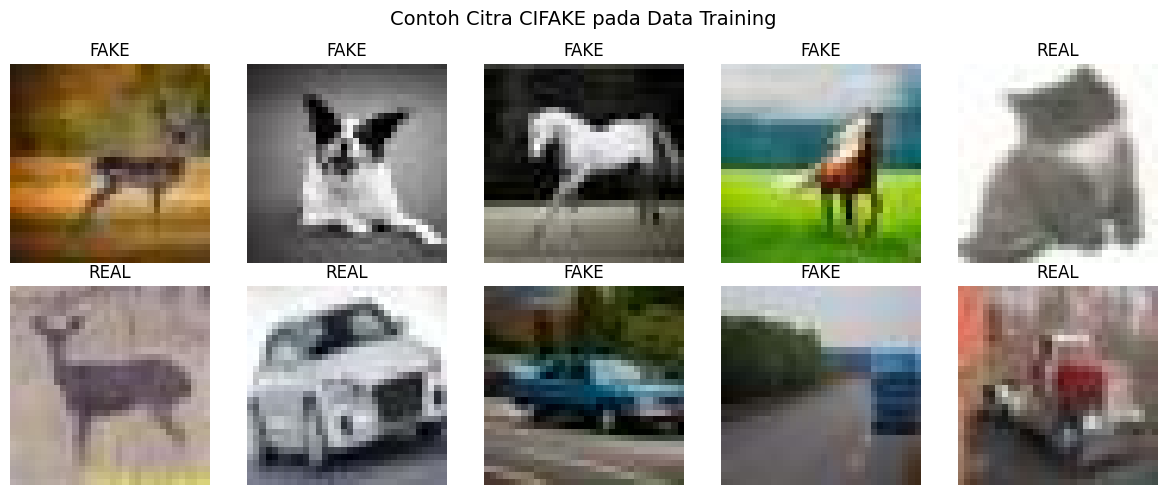

In [ ]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(images[i].numpy())

    label = CLASS_NAMES[int(labels[i].numpy())]

    plt.title(label)
    plt.axis("off")

plt.suptitle(
    "Contoh Citra CIFAKE pada Data Training",
    fontsize=14
)

plt.tight_layout()
plt.show()

# Model CNN



Model CNN digunakan untuk melakukan klasifikasi biner antara citra REAL dan FAKE.

Arsitektur yang digunakan mengikuti rancangan penelitian:

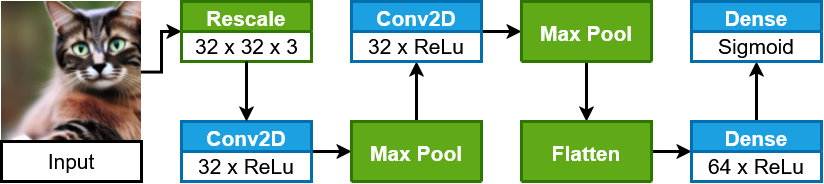

Optimizer:
Adam

Loss function:
Binary Cross Entropy

## Membangun CNN

In [ ]:
from prompt_toolkit import filters
def build_model(seed=SEED):
  # Melakukan reset state sebelum membangun model
  tf.keras.utils.set_random_seed(seed)

  model = tf.keras.Sequential(
      [
          tf.keras.layers.Input(
              shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
          ),

          # Conv Block 1
          tf.keras.layers.Conv2D(
              filters=32,
              kernel_size=(3, 3),
              activation="relu",
              name="conv2d_1"
          ),

          tf.keras.layers.MaxPooling2D(
              pool_size=(2, 2),
              name="maxpool_1"
          ),

          # Conv Block 2
          tf.keras.layers.Conv2D(
              filters=32,
              kernel_size=(3, 3),
              activation="relu",
              name="conv2d_2"
          ),

          tf.keras.layers.MaxPooling2D(
              pool_size=(2, 2),
              name="maxpool_2"
          ),

          # Classification
          tf.keras.layers.Flatten(
              name="flatten"
          ),

          tf.keras.layers.Dense(
              64,
              activation="relu",
              name="dense_64"
          ),

          tf.keras.layers.Dense(
              1,
              activation="sigmoid",
              name="output"
          )
      ],
      name="cnn_cifake"
  )

  return model

model = build_model()

print("Model Berhasil Dibangun")

Model Berhasil Dibangun


## Verifikasi Arsitektur CNN

In [ ]:
model.summary()

print("\nJumlah Parameter Total: ")
print(f"{model.count_params():,}")

print("\nVerifikasi Arsitektur Berhasil")

Model: "cnn_cifake"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,001 (328.13 KB)

 Trainable params: 84,001 (328.13 KB)

 Non-trainable params: 0 (0.00 B)


Jumlah Parameter Total: 
84,001

Verifikasi Arsitektur Berhasil


## Utility Evaluasi Model

In [ ]:
def predict_dataset(model, dataset):
  # Label Akurasi
  y_true = np.concatenate([
      label.numpy().astype(int).ravel()
      for _, labels in dataset
  ])

  # Probabilitas Prediksi
  y_prob = model.predict(dataset, verbose=0).ravel()

  # Threshold Klasifikasi
  y_pred = (y_prob >= 0.5).astype(int)

  return y_true, y_prob, y_pred

def evaluate_model(model, dataset, split_name="Test"):
  loss, accuracy = model.evaluate(dataset, verbose=0)

  y_true, y_prob, y_pred = predict_dataset(model, dataset)

  precision = precision_score(y_ture, y_pred, zero_division=0)

  recall = recall_score(y_true, y_pred, zero_devision=0)

  f1 = f1_score(y_true, y_pred, zero_devision=0)

  cm = confusion_matrix(y_true, y_pred)

  report_dict = classification_report(
      y_true,
      y_pred,
      target_names=CLASS_NAMES,
      output_dict=True,
      zero_division=0
  )

  report_df = pd.DataFrame(report_dict).T

  results = {
      "Split": split_name,
      "Loss": float(loss),
      "Accuracy": float(accuracy),
      "Precision": float(precision),
      "Recall": float(recall),
      "F1-Score": float(f1),
      "y_true": y_true,
      "y_prob": y_prob,
      "y_pred": y_pred,
      "cConfusion_Matrix": cm,
      "classification_report": report_df
  }

  return results

def get_best_epoch(history):
  val_loss = np.array(history.history["val_loss"])

  val_accuracy = np.array(history.history["val_accuracy"])

  best_lost_epoch = int(np.argmin(val_loss) + 1)

  best_accuracy_epoch = int(np.argmax(val_accuracy) + 1)

  return (
      best_lost_epoch,
      best_accuracy_epoch
  )

# Konfigurasi *Learning Rate Range Test*



Learning Rate Range Test digunakan untuk memperoleh rentang learning rate yang
akan digunakan oleh Cyclical Learning Rate.

Rancangan:

- Start learning rate = 1e-10
- End learning rate = 1e-1
- Durasi = 5 epoch
- Kenaikan learning rate dilakukan secara eksponensial melalui faktor pengali q.
- Loss dicatat pada setiap batch.

Hasil pengujian kemudian digunakan untuk menentukan:
- base_lr
- max_lr

## Menjalankan Learning Rate Range Test

In [ ]:
# Menjalankan Learning Rate Range Test
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

train_ds_lrrt = make_dataset(
    train_paths,
    train_labels,
    shuffle=True,
    seed=SEED,
    cache=False
)

steps_per_epoch = math.ceil(len(train_paths) / BATCH_SIZE)

N = LRRT_EPOCHS * steps_per_epoch

if N < 2:
    raise RuntimeError("Jumlah total step LRRT harus lebih dari 1.")

# Menghitung faktor pengali learning rate secara eksponensial
q = (LRRT_END / LRRT_START) ** (1 / (N - 1))

print("LEARNING RATE RANGE TEST\n")
print(f"Start LR          : {LRRT_START:.2e}")
print(f"End LR            : {LRRT_END:.2e}")
print(f"Epoch             : {LRRT_EPOCHS}")
print(f"Steps / epoch     : {steps_per_epoch:,}")
print(f"Total steps (N)   : {N:,}")
print(f"Multiplier (q)    : {q:.8f}")

# Membuat model khusus untuk LRRT
model_lrrt = build_model(seed=SEED)

optimizer_lrrt = tf.keras.optimizers.Adam(learning_rate=LRRT_START)

bce_loss = tf.keras.losses.BinaryCrossentropy()

lr_values = []
raw_loss_values = []
smooth_loss_values = []

beta = 0.98
avg_loss = 0.0
current_lr = LRRT_START
global_step = 0
epoch_loss_summary = []

training_stopped = False

print("\nMemulai Learning Rate Range Test...")

for epoch in range(LRRT_EPOCHS):

    epoch_raw_losses = []

    for batch_images, batch_labels in train_ds_lrrt:

        global_step += 1

        optimizer_lrrt.learning_rate.assign(current_lr)

        batch_labels = tf.reshape(batch_labels,(-1, 1))

        with tf.GradientTape() as tape:

            predictions = model_lrrt(batch_images, training=True)

            loss = bce_loss(batch_labels, predictions)

        gradients = tape.gradient(loss, model_lrrt.trainable_variables)

        optimizer_lrrt.apply_gradients(
            zip(gradients, model_lrrt.trainable_variables)
        )

        loss_value = float(loss.numpy())

        if not np.isfinite(loss_value):

            print(
                f"\nTraining dihentikan pada step "
                f"{global_step} karena loss non-finite."
            )

            training_stopped = True
            break

        avg_loss = (beta * avg_loss + (1 - beta) * loss_value)

        smooth_loss = (avg_loss/ (1 - beta ** global_step))

        lr_values.append(current_lr)

        raw_loss_values.append(loss_value)

        smooth_loss_values.append(smooth_loss)

        epoch_raw_losses.append(loss_value)

        current_lr *= q

    if epoch_raw_losses:
        epoch_mean_loss = float(np.mean(epoch_raw_losses))

        epoch_loss_summary.append(epoch_mean_loss)

        print(
            f"Epoch {epoch + 1}/{LRRT_EPOCHS} "
            f"| mean loss = {epoch_mean_loss:.6f} "
            f"| last lr = {lr_values[-1]:.2e}"
        )

    if training_stopped:
        break

print("\nLearning Rate Range Test selesai.")

lr_values = np.array(lr_values,dtype=np.float64)

raw_loss_values = np.array(raw_loss_values, dtype=np.float64)

smooth_loss_values = np.array(smooth_loss_values, dtype=np.float64)

if len(lr_values) == 0:
    raise RuntimeError("LRRT tidak menghasilkan observasi.")

lrrt_df = pd.DataFrame({
    "learning_rate": lr_values,
    "raw_loss": raw_loss_values,
    "smoothed_loss": smooth_loss_values
})

lrrt_path = (RESULTS_DIR/ "learning_rate_range_test.csv")

lrrt_df.to_csv(lrrt_path,index=False)

print("\nHASIL LRRT\n")
print(f"Jumlah observasi       : {len(lr_values):,}")
print(f"LR aktual yang tersapu : {lr_values.min():.2e} - {lr_values.max():.2e}")
print(f"Raw loss minimum       : {raw_loss_values.min():.6f}")
print(f"Smoothed loss minimum  : {smooth_loss_values.min():.6f}")
print(f"File hasil             : {lrrt_path}")

LEARNING RATE RANGE TEST

Start LR          : 1.00e-10
End LR            : 1.00e-01
Epoch             : 5
Steps / epoch     : 2,813
Total steps (N)   : 14,065
Multiplier (q)    : 1.00147458

Memulai Learning Rate Range Test...
Epoch 1/5 | mean loss = 0.695156 | last lr = 6.30e-09
Epoch 2/5 | mean loss = 0.694838 | last lr = 3.98e-07
Epoch 3/5 | mean loss = 0.671638 | last lr = 2.51e-05
Epoch 4/5 | mean loss = 0.440245 | last lr = 1.58e-03
Epoch 5/5 | mean loss = 0.441884 | last lr = 1.00e-01

Learning Rate Range Test selesai.

HASIL LRRT

Jumlah observasi       : 14,065
LR aktual yang tersapu : 1.00e-10 - 1.00e-01
Raw loss minimum       : 0.075752
Smoothed loss minimum  : 0.315597
File hasil             : /content/results/learning_rate_range_test.csv


## Visualisasi Learning Rate Range Test

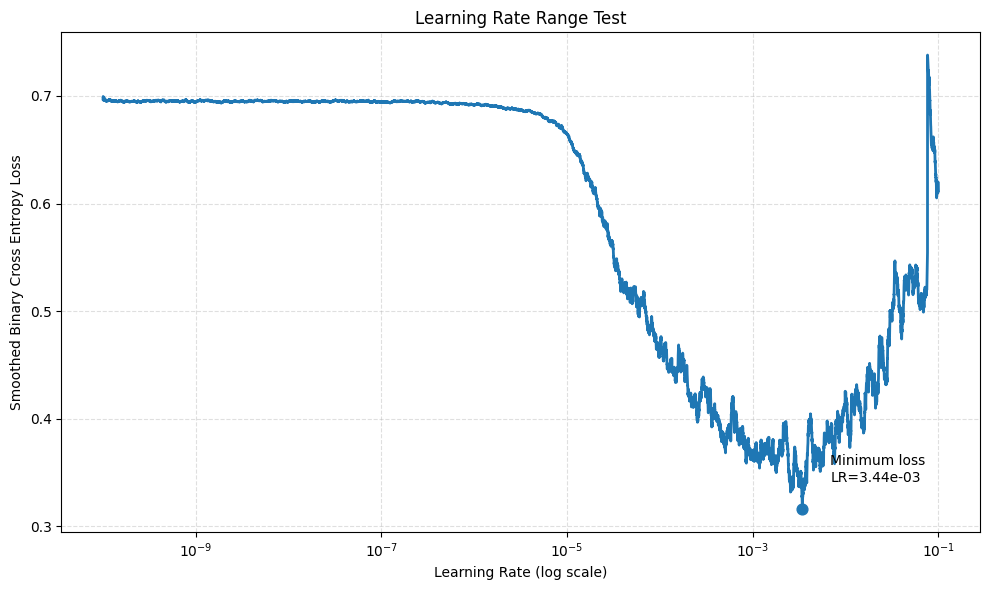


HASIL LRRT
Learning rate minimum loss : 3.44e-03
Minimum smoothed loss      : 0.315597


In [ ]:
valid_mask = (
    np.isfinite(lr_values)
    & np.isfinite(smooth_loss_values)
)

plot_lr = lr_values[valid_mask]
plot_loss = smooth_loss_values[valid_mask]

min_idx = np.argmin(plot_loss)

min_lr = plot_lr[min_idx]
min_loss = plot_loss[min_idx]

plt.figure(figsize=(10, 6))

plt.plot(
    plot_lr,
    plot_loss,
    linewidth=2
)

plt.scatter(
    [min_lr],
    [min_loss],
    s=60,
    zorder=5
)

plt.xscale("log")

plt.xlabel("Learning Rate (log scale)")

plt.ylabel("Smoothed Binary Cross Entropy Loss")

plt.title("Learning Rate Range Test")

plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

plt.annotate(
    f"Minimum loss\nLR={min_lr:.2e}",
    xy=(min_lr, min_loss),
    xytext=(20, 20),
    textcoords="offset points"
)

plt.tight_layout()
plt.show()

print("\nHASIL LRRT")
print(f"Learning rate minimum loss : {min_lr:.2e}")
print(f"Minimum smoothed loss      : {min_loss:.6f}")

## Menentukan Base LR dan Max LR

In [ ]:
# Menyaring data LRRT yang valid
valid_mask = (
    np.isfinite(lr_values) &
    np.isfinite(smooth_loss_values)
)

analysis_lr = np.asarray(lr_values)[valid_mask]
analysis_loss = np.asarray(smooth_loss_values)[valid_mask]

if len(analysis_loss) < 100:
    raise ValueError(
        "Data LRRT terlalu sedikit untuk menentukan learning rate."
    )

# Mengelompokkan data untuk membaca pola umum kurva
bin_count = min(
    300,
    max(80, int(np.sqrt(len(analysis_loss)) * 3))
)

bin_edges = np.linspace(
    0,
    len(analysis_loss),
    bin_count + 1,
    dtype=int
)

binned_lr = []
binned_loss = []
binned_indices = []

for index in range(bin_count):
    start = bin_edges[index]
    end = bin_edges[index + 1]

    if end <= start:
        continue

    binned_lr.append(
        np.median(analysis_lr[start:end])
    )

    binned_loss.append(
        np.median(analysis_loss[start:end])
    )

    binned_indices.append(
        (start + end - 1) // 2
    )

binned_lr = np.asarray(binned_lr)
binned_loss = np.asarray(binned_loss)
binned_indices = np.asarray(binned_indices)

# Menghaluskan kurva untuk membaca pola loss
smooth_window = 11

smoothed_loss = (
    pd.Series(binned_loss)
    .rolling(
        window=smooth_window,
        center=True,
        min_periods=1
    )
    .median()
    .to_numpy()
)

# Menentukan minimum loss dari seluruh data LRRT
minimum_loss_index = np.argmin(analysis_loss)

MINIMUM_LR = float(
    analysis_lr[minimum_loss_index]
)

MINIMUM_LOSS = float(
    analysis_loss[minimum_loss_index]
)

# Memetakan minimum loss ke titik binned terdekat
minimum_binned_index = np.argmin(
    np.abs(
        np.log10(binned_lr) -
        np.log10(MINIMUM_LR)
    )
)

# Menentukan BASE_LR dari knee pada sisi penurunan
base_loss_curve = smoothed_loss[
    :minimum_binned_index + 1
]

base_x = np.linspace(
    0,
    1,
    len(base_loss_curve)
)

base_loss_start = base_loss_curve[0]
base_loss_end = base_loss_curve[-1]

base_denominator = (
    base_loss_start -
    base_loss_end
)

if base_denominator <= 0:
    raise ValueError(
        "Kurva LRRT tidak menunjukkan penurunan loss yang cukup untuk menentukan BASE_LR."
    )

base_y = (
    base_loss_start -
    base_loss_curve
) / base_denominator

base_distance = base_x - base_y

base_distance[:3] = -np.inf

if len(base_distance) >= 6:
    base_distance[-3:] = -np.inf

base_binned_index = np.argmax(
    base_distance
)

base_lr_index = binned_indices[
    base_binned_index
]

BASE_LR = float(
    analysis_lr[base_lr_index]
)

# Menentukan kandidat MAX_LR setelah minimum loss
post_min_start = minimum_binned_index + 1

if post_min_start >= len(smoothed_loss) - 2:
    raise ValueError(
        "Data setelah minimum loss terlalu sedikit untuk menentukan MAX_LR."
    )

post_min_loss = smoothed_loss[
    post_min_start:
]

# Menghitung minimum loss dari setiap titik sampai akhir kurva
suffix_min_loss = np.minimum.accumulate(
    post_min_loss[::-1]
)[::-1]

# Menentukan titik yang tidak lagi dikalahkan oleh loss setelahnya
valid_max_positions = (
    post_min_loss <= suffix_min_loss + 1e-12
)

if not np.any(valid_max_positions):
    raise ValueError(
        "MAX_LR tidak dapat ditentukan dari kurva LRRT."
    )

# Mengambil titik pertama dari fase akhir kenaikan
max_relative_index = np.flatnonzero(
    valid_max_positions
)[0]

max_binned_index = (
    post_min_start +
    max_relative_index
)

max_lr_index = binned_indices[
    max_binned_index
]

MAX_LR = float(
    analysis_lr[max_lr_index]
)

MAX_LOSS_INDEX = np.argmin(
    np.abs(
        analysis_lr -
        MAX_LR
    )
)

MAX_LOSS = float(
    analysis_loss[MAX_LOSS_INDEX]
)

# Mengambil loss terendah setelah MAX_LR
later_loss = analysis_loss[
    MAX_LOSS_INDEX + 1:
]

if len(later_loss) > 0:
    LOWEST_LOSS_AFTER_MAX = float(
        np.min(later_loss)
    )
else:
    LOWEST_LOSS_AFTER_MAX = np.nan

# Menampilkan hasil penentuan learning rate
print()
print("HASIL PENENTUAN LEARNING RATE")
print()
print(
    f"BASE_LR               : {BASE_LR:.6e}"
)
print(
    f"Loss pada BASE_LR     : "
    f"{analysis_loss[np.argmin(np.abs(analysis_lr - BASE_LR))]:.6e}"
)
print()
print(
    f"Learning Rate Minimum : {MINIMUM_LR:.6e}"
)
print(
    f"Minimum Loss          : {MINIMUM_LOSS:.6e}"
)
print()
print(
    f"MAX_LR                : {MAX_LR:.6e}"
)
print(
    f"Loss pada MAX_LR      : {MAX_LOSS:.6e}"
)
print(
    f"Loss terendah setelah MAX_LR : "
    f"{LOWEST_LOSS_AFTER_MAX:.6e}"
)


HASIL PENENTUAN LEARNING RATE

BASE_LR               : 7.487901e-06
Loss pada BASE_LR     : 6.756141e-01

Learning Rate Minimum : 3.439348e-03
Minimum Loss          : 3.155967e-01

MAX_LR                : 3.757267e-03
Loss pada MAX_LR      : 3.578742e-01
Loss terendah setelah MAX_LR : 3.402004e-01


## Visualisasi Penentuan Base LR dan Max LR

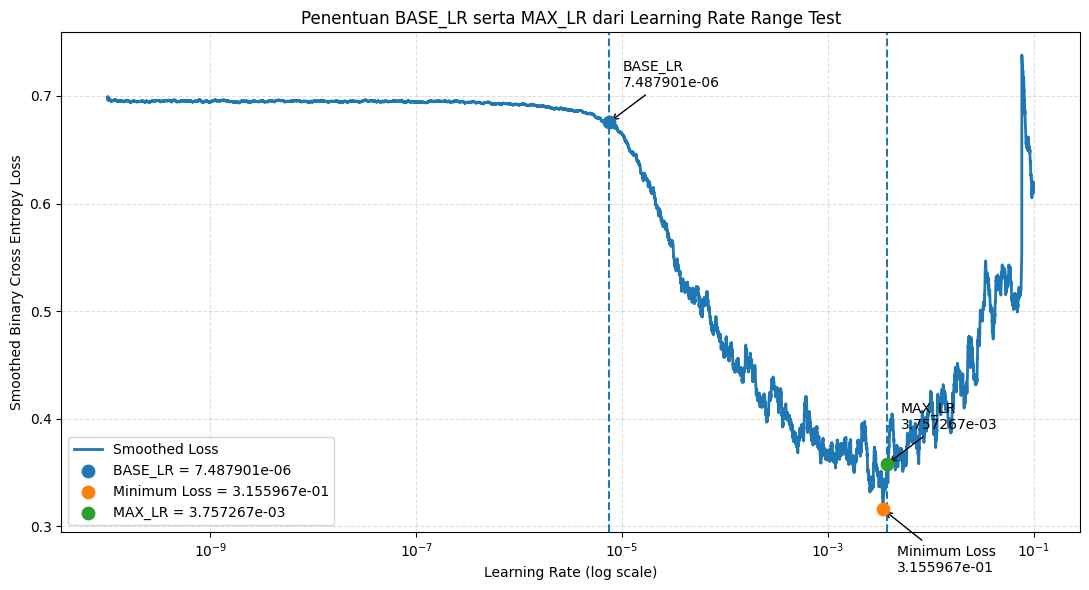

In [ ]:
# Menampilkan kurva LRRT beserta titik penentuan learning rate
plt.figure(figsize=(11, 6))

plt.plot(
    analysis_lr,
    analysis_loss,
    linewidth=2,
    label="Smoothed Loss"
)

plt.scatter(
    analysis_lr[base_lr_index],
    analysis_loss[base_lr_index],
    s=80,
    zorder=5,
    label=f"BASE_LR = {BASE_LR:.6e}"
)

plt.scatter(
    analysis_lr[minimum_loss_index],
    analysis_loss[minimum_loss_index],
    s=80,
    zorder=5,
    label=f"Minimum Loss = {analysis_loss[minimum_loss_index]:.6e}"
)

plt.scatter(
    analysis_lr[max_lr_index],
    analysis_loss[max_lr_index],
    s=80,
    zorder=5,
    label=f"MAX_LR = {MAX_LR:.6e}"
)

plt.axvline(
    BASE_LR,
    linestyle="--",
    linewidth=1.5
)

plt.axvline(
    MAX_LR,
    linestyle="--",
    linewidth=1.5
)

plt.annotate(
    f"BASE_LR\n{BASE_LR:.6e}",
    xy=(
        BASE_LR,
        analysis_loss[base_lr_index]
    ),
    xytext=(10, 25),
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="->"
    )
)

plt.annotate(
    f"Minimum Loss\n{analysis_loss[minimum_loss_index]:.6e}",
    xy=(
        analysis_lr[minimum_loss_index],
        analysis_loss[minimum_loss_index]
    ),
    xytext=(10, -45),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    f"MAX_LR\n{MAX_LR:.6e}",
    xy=(
        MAX_LR,
        analysis_loss[max_lr_index]
    ),
    xytext=(10, 25),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.xscale("log")

plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Smoothed Binary Cross Entropy Loss")
plt.title("Penentuan BASE_LR serta MAX_LR dari Learning Rate Range Test")

plt.legend()

plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

# Eksperimen 1 - *Fixed Learning Rate*

Model CNN dilatih menggunakan *learning rate* tetap selama proses pelatihan

Konfigurasi:
- Optimizer: Adam
- Loss: *Binary Cross Entropy*
- Learning Rate: 0.001 atau 10e-3
- Epoch Maksimum: 50
- Dataset: CIFAKE
- Arsitektur: CNN yang telah ditetapkan

Model terbaik dipilih berdasarkan nilai validation loss terendah.


In [ ]:
# Membuat model dan checkpoint untuk skenario Fixed Leaerning Rate
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model_fixed = build_model(seed=SEED)

model_fixed.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FIXED_LR),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

fixed_checkpoint_path = (CHECKPOINT_DIR / "fixed_best.weights.h5")

checkpoint_fixed = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(fixed_checkpoint_path),
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=True,
    verbose=0
)

history_fixed = model_fixed.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_fixed],
    verbose=1
)

model_fixed.load_weights(fixed_checkpoint_path)

best_epoch_fixed = (np.argmin(history_fixed.history["val_loss"]) + 1)

best_val_loss_fixed = (
    history_fixed.history["val_loss"][best_epoch_fixed - 1]
)

best_val_accuracy_fixed = (history_fixed.history["val_accuracy"][best_epoch_fixed - 1])

print("\nHASIL PELATIHAN FIXED LEARNING RATE\n")
print(f"Learning rate       : {FIXED_LR:.2e}")
print(f"Epoch pelatihan     : {EPOCHS}")
print(f"Epoch terbaik       : {best_epoch_fixed}")
print(f"Best validation loss: {best_val_loss_fixed:.6f}")
print(f"Validation accuracy : {best_val_accuracy_fixed:.6f}")

## Visualisasi Loss *Fixed Learning Rate*

In [ ]:
# Menampilkan kurva loss pelatihan Fixed Learning Rate
epochs_range = range(
    1,
    len(history_fixed.history["loss"]) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    history_fixed.history["loss"],
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history_fixed.history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch_fixed,
    linestyle="--",
    label=f"Best Epoch = {best_epoch_fixed}"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Loss Fixed Learning Rate")
plt.legend()
plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

## Visualisasi Accuracy Fixed Learning Rate

In [ ]:
# Menampilkan kurva accuracy pelatihan Fixed Learning Rate
plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    history_fixed.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history_fixed.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.axvline(
    best_epoch_fixed,
    linestyle="--",
    label=f"Best Epoch = {best_epoch_fixed}"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Fixed Learning Rate")
plt.legend()
plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

## Evaluasi Fixed Learning Rate pada Data Testing

In [ ]:
# Mengevaluasi model terbaik pada data pengujian
test_results_fixed = model_fixed.evaluate(
    test_ds,
    verbose=0,
    return_dict=True
)

y_true_fixed = []
y_probability_fixed = []

for batch_images, batch_labels in test_ds:

    batch_probability = model_fixed.predict(
        batch_images,
        verbose=0
    ).reshape(-1)

    y_true_fixed.extend(
        batch_labels.numpy().astype(int)
    )

    y_probability_fixed.extend(
        batch_probability
    )

y_true_fixed = np.array(
    y_true_fixed
)

y_probability_fixed = np.array(
    y_probability_fixed
)

y_pred_fixed = (
    y_probability_fixed >= 0.5
).astype(int)

fixed_accuracy = accuracy_score(
    y_true_fixed,
    y_pred_fixed
)

fixed_precision = precision_score(
    y_true_fixed,
    y_pred_fixed,
    zero_division=0
)

fixed_recall = recall_score(
    y_true_fixed,
    y_pred_fixed,
    zero_division=0
)

fixed_f1 = f1_score(
    y_true_fixed,
    y_pred_fixed,
    zero_division=0
)

fixed_test_loss = test_results_fixed["loss"]

print("HASIL EVALUASI FIXED LEARNING RATE\n")

print(f"Test Loss     : {fixed_test_loss:.6f}")
print(f"Test Accuracy : {fixed_accuracy:.6f}")
print(f"Test Precision: {fixed_precision:.6f}")
print(f"Test Recall   : {fixed_recall:.6f}")
print(f"Test F1-Score : {fixed_f1:.6f}")

## Classification Report dan Confusion Matrix Fixed Learning Rate

In [ ]:
# Menampilkan classification report dan confusion matrix
print("CLASSIFICATION REPORT\n")

print(
    classification_report(
        y_true_fixed,
        y_pred_fixed,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

confusion_fixed = confusion_matrix(
    y_true_fixed,
    y_pred_fixed
)

print("CONFUSION MATRIX\n")
print(confusion_fixed)

ConfusionMatrixDisplay(
    confusion_matrix=confusion_fixed,
    display_labels=CLASS_NAMES
).plot()

plt.title(
    "Confusion Matrix Fixed Learning Rate"
)

plt.tight_layout()
plt.show()

## Menyimpan hasil Fixed Learning Rate

In [ ]:
# Menyimpan hasil evaluasi Fixed Learning Rate
fixed_results = pd.DataFrame([
    {
        "Strategy": "Fixed Learning Rate",
        "Best Epoch": best_epoch_fixed,
        "Test Loss": fixed_test_loss,
        "Test Accuracy": fixed_accuracy,
        "Test Precision": fixed_precision,
        "Test Recall": fixed_recall,
        "Test F1-Score": fixed_f1
    }
])

display(
    fixed_results
)

fixed_results.to_csv(
    RESULTS_DIR / "fixed_test_results.csv",
    index=False
)

# Eksperimen 2 - *Cyclical Learning Rate*

Cyclical Learning Rate (CLR) digunakan dengan mode Triangular2

Pada metode ini, learning rate bergerak secara periodik antara base_lr dan max_lr

Mode Traingular2 mempertahankan pola siklik tetapi amplitudo siklus berikutnya dikurangi menjadi setengah dari siklus sebelumnya.

Parameter CLR:
- base_lr
- max_lr
- step_size
- mode = Triangular2

## Implementasi Triangular2

In [ ]:
class Triangular2LearningRate(
    tf.keras.optimizers.schedules.LearningRateSchedule
):

    def __init__(
        self,
        base_lr,
        max_lr,
        step_size
    ):
        super().__init__()

        self.base_lr = float(base_lr)
        self.max_lr = float(max_lr)
        self.step_size = float(step_size)

    def __call__(self, step):

        step = tf.cast(step, tf.float32)

        cycle = tf.floor(1.0 + step / (2.0 * self.step_size))

        x = tf.abs(step / self.step_size - 2.0 * cycle + 1.0)

        scale = tf.maximum(0.0, 1.0 - x)

        amplitude = (self.max_lr - self.base_lr)

        lr = (self.base_lr + (amplitude * scale / tf.pow(2.0, cycle - 1.0)))

        return lr

    def get_config(self):

        return {
            "base_lr": self.base_lr,
            "max_lr": self.max_lr,
            "step_size": self.step_size
        }


print("Class Triangular2LearningRate berhasil dibuat.")

## Konfigurasi CLR

In [ ]:
if BASE_LR is None or MAX_LR is None:
    raise ValueError("BASE_LR dan MAX_LR belum ditentukan.")

STEP_SIZE = (STEP_SIZE_MULTIPLIER * STEPS_PER_EPOCH)

clr_schedule = Triangular2LearningRate(base_lr=BASE_LR,max_lr=MAX_LR,step_size=STEP_SIZE)

TOTAL_TRAINING_STEPS = (EPOCHS* STEPS_PER_EPOCH)

print("KONFIGURASI CLR")

print(f"base_lr: {BASE_LR:.2e}")
print(f"max_lr: {MAX_LR:.2e}")
print(f"steps/epoch: {STEPS_PER_EPOCH:,}")
print(f"step_size: {STEP_SIZE:,}")
print(f"total steps: {TOTAL_TRAINING_STEPS:,}")
print(f"cycle penuh   : {2 * STEP_SIZE:,} steps")

## Visualisasi CLR Schedule

In [ ]:
# Agar grafik tetap ringan,
# cukup plot maksimal 10.000 titik.
plot_count = min(TOTAL_TRAINING_STEPS,10000)

steps_for_plot = np.linspace(
    0,
    TOTAL_TRAINING_STEPS - 1,
    plot_count,
    dtype=np.int64
)

lr_curve = clr_schedule(
    tf.constant(steps_for_plot, dtype=tf.float32)
).numpy()

plt.figure(figsize=(12, 6))

plt.plot(
    steps_for_plot,
    lr_curve,
    linewidth=2
)

plt.xlabel("Training Iteration")
plt.ylabel("Learning Rate")

plt.title("Cyclical Learning Rate - Triangular2")

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

print("VERIFIKASI CLR")

print(f"LR minimum : {lr_curve.min():.6e}")
print(f"LR maksimum : {lr_curve.max():.6e}")

## Training CLR

In [ ]:
tf.keras.backend.clear_session()
gc.collect()

tf.keras.utils.set_random_seed(SEED)

clr_checkpoint = (
    CHECKPOINT_DIR
    / "clr_best.weights.h5"
)

if clr_checkpoint.exists():
    clr_checkpoint.unlink()

# Model baru
model_clr = build_model(
    seed=SEED
)

model_clr.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=clr_schedule
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Dataset training baru
train_ds_clr = make_dataset(
    train_paths,
    train_labels,
    shuffle=True,
    seed=SEED,
    cache=False
)

checkpoint_clr = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(clr_checkpoint),
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=True,
    verbose=0
)

print("TRAINING CLR TRIANGULAR2")
print(f"base_lr: {BASE_LR:.2e}")
print(f"max_lr: {MAX_LR:.2e}")
print(f"step_size: {STEP_SIZE:,}")
print(f"epochs: {EPOCHS}")

history_clr = model_clr.fit(
    train_ds_clr,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint_clr],
    verbose=2
)

# Load model terbaik
model_clr.load_weights(
    clr_checkpoint
)

# Simpan history
history_clr_df = pd.DataFrame(history_clr.history)

history_clr_df.index = (history_clr_df.index + 1)

history_clr_df.index.name = "epoch"

history_clr_df.to_csv(RESULTS_DIR / "history_clr.csv")

print("\nModel CLR terbaik berhasil dimuat.")

## Grafik Loss CLR

In [ ]:
epochs_axis_clr = np.arange(
    1,
    len(
        history_clr.history["loss"]
    ) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_axis_clr,
    history_clr.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    epochs_axis_clr,
    history_clr.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")

plt.title(
    "Training dan Validation Loss — CLR Triangular2"
)

plt.legend()

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

## Grafik Accuracy CLR

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs_axis_clr,
    history_clr.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    epochs_axis_clr,
    history_clr.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training dan Validation Accuracy — CLR Triangular2"
)

plt.legend()

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

## Epoch Terbaik CLR

In [ ]:
clr_best_epoch, clr_best_acc_epoch = (
    get_best_epoch(history_clr)
)

clr_best_val_loss = (
    history_clr.history["val_loss"][
        clr_best_epoch - 1
    ]
)

clr_best_val_accuracy = (
    history_clr.history["val_accuracy"][
        clr_best_epoch - 1
    ]
)

clr_best_acc_value = (
    history_clr.history["val_accuracy"][
        clr_best_acc_epoch - 1
    ]
)

print("EPOCH TERBAIK — CLR TRIANGULAR2")

print(
    f"Best epoch berdasarkan val_loss : "
    f"{clr_best_epoch}"
)

print(
    f"Best validation loss            : "
    f"{clr_best_val_loss:.6f}"
)

print(
    f"Validation accuracy pada epoch : "
    f"{clr_best_val_accuracy:.6f}"
)

print(
    f"Epoch validation accuracy max  : "
    f"{clr_best_acc_epoch}"
)

print(
    f"Maximum validation accuracy    : "
    f"{clr_best_acc_value:.6f}"
)


## Evaluasi Test CLR

In [ ]:
clr_eval = evaluate_model(
    model_clr,
    test_ds,
    split_name="Test CLR"
)

print("=" * 60)
print("HASIL TEST — CLR TRIANGULAR2")
print("=" * 60)

print(
    f"Loss       : {clr_eval['Loss']:.6f}"
)

print(
    f"Accuracy   : {clr_eval['Accuracy']:.6f}"
)

print(
    f"Precision  : {clr_eval['Precision']:.6f}"
)

print(
    f"Recall     : {clr_eval['Recall']:.6f}"
)

print(
    f"F1-score   : {clr_eval['F1-score']:.6f}"
)

print("=" * 60)

print("\nClassification Report:")

display(
    clr_eval[
        "classification_report"
    ]
)

## Confusion Matrix CLR

In [ ]:
clr_cm = clr_eval[
    "confusion_matrix"
]

tn, fp, fn, tp = clr_cm.ravel()

print("=" * 60)
print("CONFUSION MATRIX — CLR")
print("=" * 60)

print(f"True Negative  (TN) : {tn:,}")
print(f"False Positive (FP) : {fp:,}")
print(f"False Negative (FN) : {fn:,}")
print(f"True Positive  (TP) : {tp:,}")

print("=" * 60)

disp = ConfusionMatrixDisplay(
    confusion_matrix=clr_cm,
    display_labels=CLASS_NAMES
)

disp.plot(
    values_format="d"
)

plt.title(
    "Confusion Matrix — CLR Triangular2"
)

plt.tight_layout()
plt.show()

# Perbandingan FLR dan CLR

## Matrix

In [ ]:
comparison = pd.DataFrame({

    "Metric": [
        "Loss",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Fixed LR": [
        fixed_eval["Loss"],
        fixed_eval["Accuracy"],
        fixed_eval["Precision"],
        fixed_eval["Recall"],
        fixed_eval["F1-score"]
    ],

    "CLR Triangular2": [
        clr_eval["Loss"],
        clr_eval["Accuracy"],
        clr_eval["Precision"],
        clr_eval["Recall"],
        clr_eval["F1-score"]
    ]
})

comparison[
    "Delta (CLR - Fixed)"
] = (
    comparison["CLR Triangular2"]
    - comparison["Fixed LR"]
)

print("=" * 60)
print("PERBANDINGAN HASIL EKSPERIMEN")
print("=" * 60)

display(
    comparison.style.format({
        "Fixed LR": "{:.6f}",
        "CLR Triangular2": "{:.6f}",
        "Delta (CLR - Fixed)": "{:+.6f}"
    })
)

comparison.to_csv(
    RESULTS_DIR / "comparison_fixed_vs_clr.csv",
    index=False
)

## Perbandingan Validation Loss

In [ ]:
epochs_common = np.arange(
    1,
    EPOCHS + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_common,
    history_fixed.history["val_loss"],
    label="Fixed LR",
    linewidth=2
)

plt.plot(
    epochs_common,
    history_clr.history["val_loss"],
    label="CLR Triangular2",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title(
    "Perbandingan Validation Loss"
)

plt.legend()

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

## Perbandingan Validation Accuracy

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs_common,
    history_fixed.history["val_accuracy"],
    label="Fixed LR",
    linewidth=2
)

plt.plot(
    epochs_common,
    history_clr.history["val_accuracy"],
    label="CLR Triangular2",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.title(
    "Perbandingan Validation Accuracy"
)

plt.legend()

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

# Ringkasan Eksperimen

In [ ]:
experiment_summary = pd.DataFrame({

    "Parameter": [
        "Training images",
        "Validation images",
        "Testing images",
        "Batch size",
        "Epoch maksimum",
        "Fixed learning rate",
        "LRRT start",
        "LRRT end",
        "LRRT epochs",
        "CLR base_lr",
        "CLR max_lr",
        "CLR step_size",
        "Fixed best epoch",
        "CLR best epoch",
        "Fixed test loss",
        "CLR test loss",
        "Fixed test accuracy",
        "CLR test accuracy",
        "Fixed test precision",
        "CLR test precision",
        "Fixed test recall",
        "CLR test recall",
        "Fixed test F1",
        "CLR test F1"
    ],

    "Value": [
        len(train_paths),
        len(val_paths),
        len(test_paths),
        BATCH_SIZE,
        EPOCHS,
        FIXED_LR,
        LRRT_START,
        LRRT_END,
        LRRT_EPOCHS,
        BASE_LR,
        MAX_LR,
        STEP_SIZE,
        fixed_best_epoch,
        clr_best_epoch,
        fixed_eval["Loss"],
        clr_eval["Loss"],
        fixed_eval["Accuracy"],
        clr_eval["Accuracy"],
        fixed_eval["Precision"],
        clr_eval["Precision"],
        fixed_eval["Recall"],
        clr_eval["Recall"],
        fixed_eval["F1-score"],
        clr_eval["F1-score"]
    ]
})

display(
    experiment_summary
)

experiment_summary.to_csv(
    RESULTS_DIR / "experiment_summary.csv",
    index=False
)

print(
    f"\nSemua hasil eksperimen disimpan di: "
    f"{RESULTS_DIR}"
)